In [ ]:
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

### Minimzing the Cost Function

In [ ]:
# np.random.rand generates random floating-point numbers from a uniform distribution over the interval [0.0, 1.0)
X = 2 * np.random.rand(100,1)  #Generates a 2D matrix of 100x1 with values
y = 4 + 3 * X + np.random.rand(100,1)  #adding gausian noise

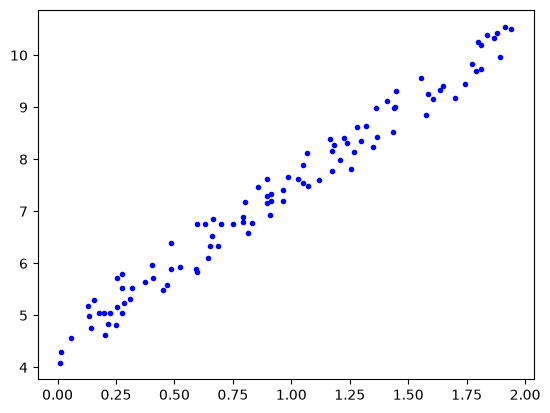

In [23]:
plt.plot(X, y, "b.")
plt.show()

#### Normal equation

$$
\boldsymbol{\theta} = (X^T X)^{-1} X^T y
$$

where:

- $\boldsymbol{\theta}$ is the value of $\theta$ that minimizes the cost function.
- $y$ is the vector of target values containing $y^{(1)}$ to $y^{(m)}$.

In [19]:
X_b = np.c_[np.ones((100,1)), X]  # add x0 = 1 to each instance

theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.44138259],
       [3.06951017]])

The actual function that we used to generate the data is y = 4 + 3 $x_{1}$ + Gaussian noise. 
We would have hoped for ${\theta}_0$= 4 and ${\theta}_1$= 3 instead of ${\theta}_0$ = 4.44 and ${\theta}_1$= 3.06. Close
enough, but the noise made it impossible to recover the exact parameters of the original function

In [20]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.44138259],
       [10.58040293]])

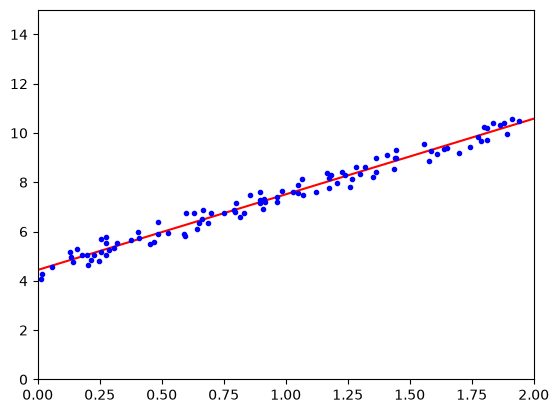

In [24]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")

plt.axis([0, 2, 0, 15])
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression

lg = LinearRegression()
lg.fit(X,y)
lg.intercept_ , lg.coef_

(array([4.44138259]), array([[3.06951017]]))

In [27]:
lg.predict(X_new)

array([[ 4.44138259],
       [10.58040293]])

Using LinearRegression gives the same values for ${\theta}_0$ and ${\theta}_1$ as well as the predicted values.

### Using Batch Gradient Descent

$$
\frac{\partial}{\partial \theta_j}\mathrm{MSE}(\theta)
=
\frac{2}{m}\sum_{i=1}^{m}
\left(\theta^T x^{(i)}-y^{(i)}\right)x_j^{(i)}
$$



$$
\theta_{\text{next step}} = \theta - \eta \nabla_{\theta} \mathrm{MSE}(\theta)
$$

where:

- $\nabla_{\theta}\mathrm{MSE}(\theta)$ is the gradient vector which contains all the partial derivatives of the cost function (one for each model parameter)

In [31]:
eta = [0.02, 0.1, 0.5] #learning rate
n_iterations = 1000
m = 100  #number of obs

theta_list = []

initial_theta = np.random.randn(2,1) #random initialization

for eta_value in eta:
    theta = initial_theta
    for iteration in range(n_iterations):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta_value * gradients
    theta_list.append(theta)
theta_list

[array([[4.43973755],
        [3.07099838]]),
 array([[4.44138259],
        [3.06951017]]),
 array([[-1.28583091e+17],
        [-1.42133359e+17]])]

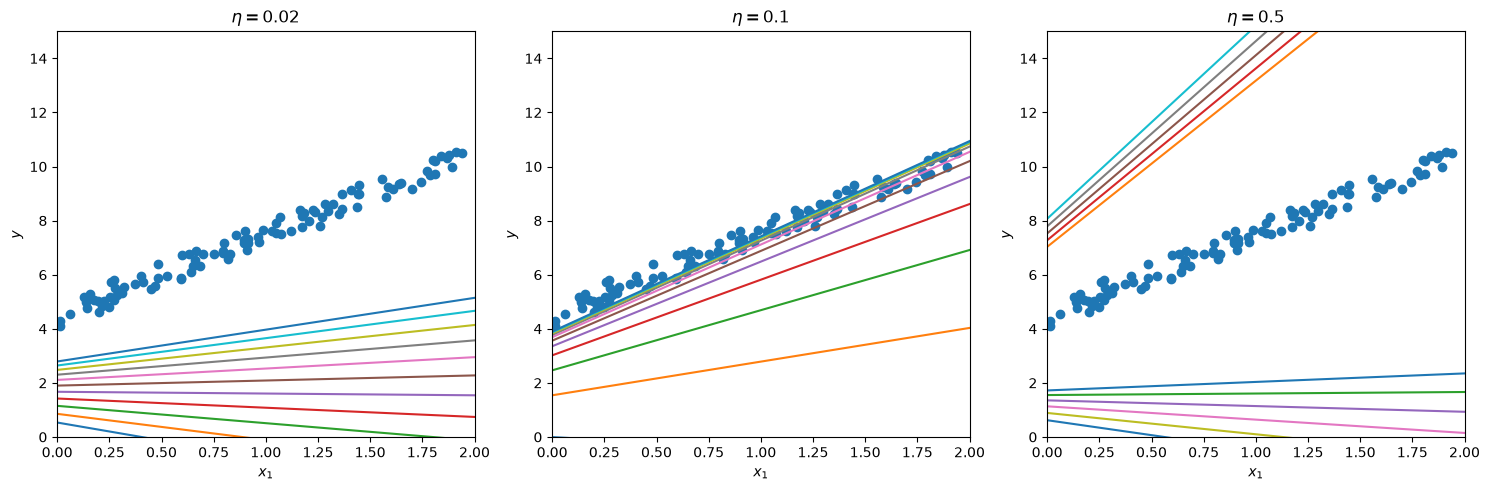

In [36]:
def gradient_descent(X, y, eta, n_iterations=20):
    m = len(X)
    
    # Starting point
    theta = np.random.randn(2, 1)
    
    theta_history = [theta.copy()]
    
    for iteration in range(n_iterations):
        
        # Calculate gradient
        gradients = (2 / m) * X.T @ (X @ theta - y)
        
        # Update theta
        theta = theta - eta * gradients
        
        theta_history.append(theta.copy())
    
    return theta_history

learning_rates = [0.02, 0.1, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, eta in zip(axes, learning_rates):
    
    theta_history = gradient_descent(
        X_b, 
        y, 
        eta, 
        n_iterations=10
    )
    
    # Plot data
    ax.scatter(X, y)
    
    # Plot regression line after every iteration
    X_new = np.array([[0], [2]])
    X_new_b = np.c_[np.ones((2, 1)), X_new]
    
    for theta in theta_history:
        y_predict = X_new_b @ theta
        
        ax.plot(
            X_new,
            y_predict
        )
    
    ax.set_title(f"$\\eta = {eta}$")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$y$")
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

On the left, the learning rate is too low: the algorithm will eventually reach the solution, but it will take a long time. In the middle, the learning rate looks pretty good: in just a few iterations, it has already converged to the solution. On the right, the learning rate is too high: the algorithm diverges, jumping all over the place and actually getting further and further away from the solution at every step.

### Ploynomial Regression